# VPT for Higher Energy Levels

This file is basically the same as the other VPT notebook but I've generalized some of the functions to work with higher energy levels. Perhaps this is better suited for that file, but I think it's better to separate it and not make any breaking changes unnecessarily. The ideas are all exactly the same, I just include a new "n" argument to some of the functions below, which is where I enter the energy level I want to work with. 

I've also included the stuff about minimizing $\langle x^2 \rangle$.

Again, basic imports + TeXifying stuff.

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from tabulate import tabulate
import seaborn as sns

In [2]:
plt.rcParams["mathtext.fontset"] = "cm"
plt.rc('font', family='serif',size=12)
plt.rc('text', usetex=True)

Same constants as before, same functions as before, but note again that the functions relevant to the VPT process have a new argument, "n" to work with an arbitrary energy level of choice. Note also the two extra helper functions that help calculate  $\langle x^2 \rangle$.

In [3]:
g=0.2
m = 1       # mass
w = 1       # supposed to be omega i.e. frequency of harmonic oscillator
hb = 1      # short for hbar

b = 10.0    # integral upper bound for Gauss-Legendre quadrature
a = -10.0   # integral lower bound for Gauss-Legendre quadrature (G-L Q)

c1 = (b-a)/2    # these two helper variables are convenient to calculate change of interval for G-L Q
c2 = (b+a)/2

samples, weights = np.polynomial.legendre.leggauss(99)      # G-L Q sample points & weights

In [4]:
#the wavefunction that solves the unperturbed Hamiltonian
def wavefunction(n, x, Omega):
    freq = np.sqrt(w**2 + Omega**2)
    xi = x * np.sqrt(m*freq/hb)
    return np.exp(-(xi**2)/2) * (m*freq /(np.pi*hb))**(1/4) * ((2**n)*sp.special.factorial(n))**(-1/2) * sp.special.eval_hermite(n, xi)

#the second derivative of the above wavefunction w.r.t. x. I'm just using a central difference formula here. 
def dd_wavefunction(n, x, Omega):
    h=1e-4
    return (wavefunction(n, x+h, Omega) - 2*wavefunction(n, x, Omega) + wavefunction(n, x-h, Omega)) / h**2

#the action of the unperturbed Hamiltonian on the unperturbed wavefunctions
def H0psi(n, x, Omega):
    return -(hb**2)/(2*m) * dd_wavefunction(n, x, Omega) + (1.0/2)*m*(Omega**2 + w**2)*(x**2) * wavefunction(n, x, Omega)

#perturbation to the Hamiltonian
def H1(x, Omega):
    return g*(x**4) - (1.0/2)*m*(Omega**2)*(x**2)

# transition amplitude, i.e. the integrand of the energy expectation value integral
def trans_amp(n1, n2, x, Omega):
    return wavefunction(n2, x, Omega) * H0psi(n1, x, Omega) + trans_amp_pert(n1, n2, x, Omega)

#same as trans_amp but for the perturbation alone. There is a use for this alone (see E1, E2 below) which is why I've separated it. 
def trans_amp_pert(n1, n2, x, Omega):
    return wavefunction(n1, x, Omega) * H1(x, Omega) * wavefunction(n2, x, Omega)

#zeroth order energy, i.e. energy of the unperturbed Hamiltonian
def E0(n, Omega):
    return (n*1.0 + 1.0/2)*hb*np.sqrt(w**2 + Omega**2)

# The following two functions are classic perturbation theory results, nothing special. The integrals are evaluated using Gauss-Legendre quadrature.

#first order energy correction as a result of the quartic perturbation
def E1(n, Omega):
    return c1 * np.dot(weights, trans_amp_pert(n, n, c1*samples + c2, Omega))

#second order energy correction due to quartic perturbation
def E2(n, Omega):
    E_2 = 0
    # with some more analysis you can show that you can skip every other term, but we'll keep it general
    for i in range(0, n + 5):
        if (i == n):
            continue 

        integral = c1 * np.dot(weights, trans_amp_pert(n, i, c1*samples + c2, Omega))
        E_2 += integral**2 / (E0(n, Omega) - E0(i, Omega))

    return E_2

# first order total energy. This is the function we will be minimizing to get the Omega value. 
def energy1o(n, Omega):
    return E0(n, Omega) + E1(n, Omega)

# second order total energy. We'll minimize this and show that it gives squat. 
def energy2o(n, Omega):
    return E0(n, Omega) + E1(n, Omega)  + E2(n, Omega)

# just a central difference derivative of the first order total energy. It's convenient. 
def first_derivative_1o(n, Omega):
    h=1e-5
    return (energy1o(n, Omega + h) - energy1o(n, Omega - h)) / (2*h)

# just a central difference derivative of the second order total energy. It's convenient. 
def first_derivative_2o(n, Omega):
    h=1e-5
    return (energy2o(n, Omega + h) - energy2o(n, Omega - h)) / (2*h)

First I want to make an elementary graph that plots how $\Omega$ changes as $n$ is increased. It seems to be something like a $\ln(x)$ curve but there's no way to know with this small of a range. As $n$ becomes large it looks like the optimizer goes a little wild, though (which is expected I think), so I'm not sure this can go much farther. 

In [6]:
nvals = np.arange(20)

Omega_1o = np.zeros_like(nvals) + 0.01
Omega_2o = np.zeros_like(nvals) + 0.01

for i in range(len(nvals)):
    Omega_1o[i] = sp.optimize.minimize(lambda x: energy1o(nvals[i], x), x0=[1.0], bounds=[(1e-6, None)]).x[0]
    Omega_2o[i] = sp.optimize.minimize(lambda x: first_derivative_2o(nvals[i], x), x0=[1.0], bounds=[(1e-6, None)]).x[0]

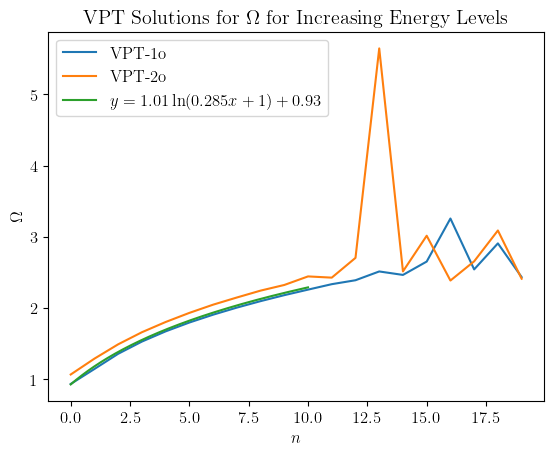

In [44]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

ax.plot(nvals, Omega_1o, label='VPT-1o')
ax.plot(nvals, Omega_2o, label='VPT-2o')

xvals = np.arange(0, 10, 0.001)
ax.plot(xvals, 1.01*np.log(0.285*xvals + 1) + 0.93, label='$y=1.01\\ln(0.285x+1) + 0.93$')

ax.set_title('VPT Solutions for $\\Omega$ for Increasing Energy Levels')
ax.set_ylabel('$\\Omega$')
ax.set_xlabel('$n$')
ax.legend()

Now comes the heatmap stuff. Again, same exact code, but now I am introducing the new parameter to the code. Here I'm working with higher energy levels, not the  $\langle x^2 \rangle$ stuff yet. The first constant in this blob of code controls the energy level and the rest is just copy-pasted from the VPT notebook. Size can be varied if you want to "zoom out" or "zoom in", so to speak.

In [132]:
e_lvl = 7
Omega_1o = sp.optimize.minimize(lambda x: energy1o(e_lvl, x), x0=[1.0], bounds=[(1e-6, None)]).x[0]
Omega_2o = sp.optimize.minimize(lambda x: first_derivative_2o(e_lvl, x), x0=[1.0], bounds=[(1e-6, None)]).x[0]

size = 20
energy_matrix1 = np.zeros((size, size))

for i in range(size):
    for j in range(i, size):
        integral = c1 * np.dot(weights, trans_amp(i, j, c1*samples + c2, 0))

        energy_matrix1[i][j] = integral
        energy_matrix1[j][i] = integral


energy_matrix2 = np.zeros((size, size))

for i in range(size):
    for j in range(i, size):
        integral = c1 * np.dot(weights, trans_amp(i, j, c1*samples + c2, Omega_1o))

        energy_matrix2[i][j] = integral
        energy_matrix2[j][i] = integral


energy_matrix3 = np.zeros((size, size))

for i in range(size):
    for j in range(i, size):
        integral = c1 * np.dot(weights, trans_amp(i, j, c1*samples + c2, Omega_2o))

        energy_matrix3[i][j] = integral
        energy_matrix3[j][i] = integral

        
# table = tabulate(np.round(energy_matrix, decimals=4), tablefmt="fancy_grid")
# print(table)


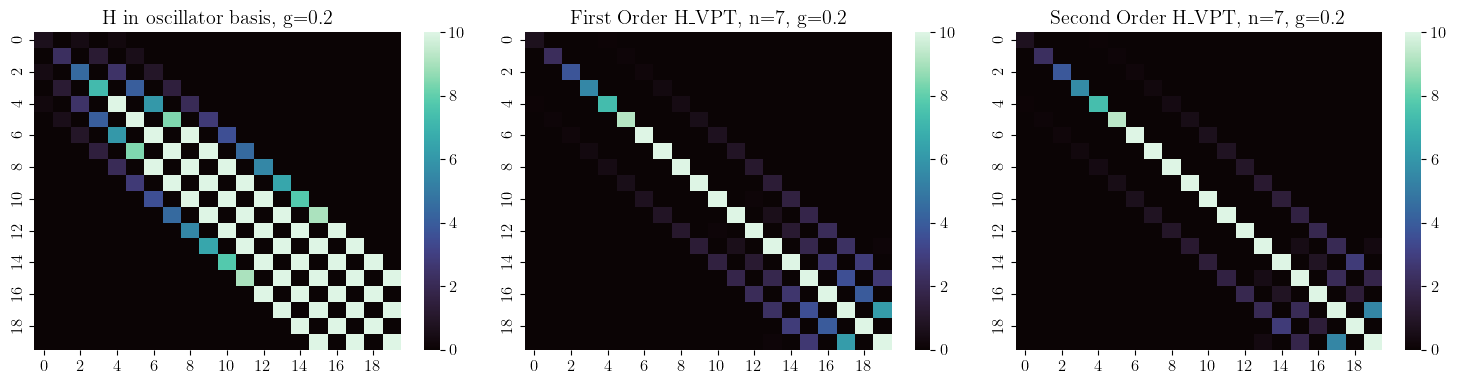

In [133]:
fig = plt.figure(figsize=(15, 4))
ax1 = fig.add_subplot(1, 3, 1)
ax2 = fig.add_subplot(1, 3, 2)
ax3 = fig.add_subplot(1, 3, 3)
ax1.set_title('H in oscillator basis, g=0.2')
ax2.set_title(f'First Order H_VPT, n={e_lvl}, g={g}')
ax3.set_title(f'Second Order H_VPT, n={e_lvl}, g={g}')
sns.heatmap(energy_matrix1, ax=ax1, vmax = 10, vmin=0, cmap='mako')
sns.heatmap(energy_matrix2, ax=ax2, vmax = 10, vmin=0, cmap ='mako')
sns.heatmap(energy_matrix3, ax=ax3, vmax = 10, vmin=0, cmap = 'mako')

fig.tight_layout()
plt.show()


Now we get to minimizing  $\langle x^2 \rangle$ (well, not necessarily minimizing as we'll see).

This time the methodology is a little different: we find the corrections to the wavefunctions and then expand the expectation value perturbatively. Let's first check out zeroth order, particularly the ground state and show that there is no minimum to find (i.e. if you find the expectation value using the zeroth-order ground state wavefunction). You will also see that as the energy level is increased, a minimum does start to form but it's at some very large $\Omega$. That predicts a very high ground state energy consequently so it's not exactly sensible for that purpose. I'll just make a quick plot showcasing that and then move on. 

First I'm going to define a couple helper function just to make things a bit readable.

In [6]:
# zeroth-order integrand for x^2 expectation value
def x_sq_integrand_0o(n, x, Omega):
    return wavefunction(n, x, Omega) * (x)**2 * wavefunction(n, x, Omega)

#zeroth-order x^2 expectation value
def x_sq_expval_0o(n, Omega):
    return c1 * np.dot(weights, x_sq_integrand_0o(n, c1*samples + c2, Omega))

In [25]:
xvals = np.arange(0.001, 50, 0.001)
yvals_0 = [x_sq_expval_0o(0,x) for x in xvals]
yvals_5 = [x_sq_expval_0o(5, x) for x in xvals]
yvals_10 = [x_sq_expval_0o(10, x) for x in xvals]

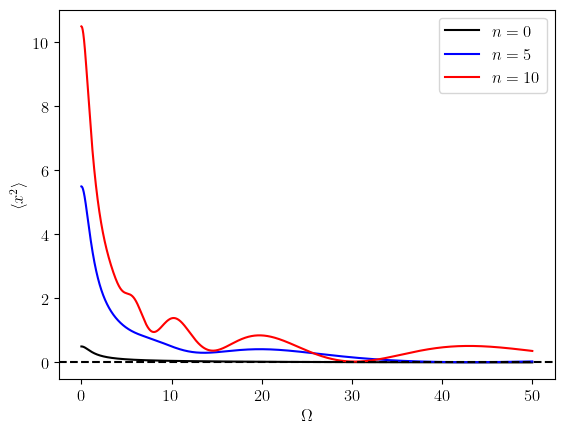

In [26]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

ax.plot(xvals, yvals_0, color='black', label='$n=0$')
ax.plot(xvals, yvals_5, color='blue', label='$n=5$')
ax.plot(xvals, yvals_10, color='red', label='$n=10$')

ax.axhline(0, color='black', linestyle='--')
ax.set_xlabel('$\\Omega$')
ax.set_ylabel('$\\langle x^2 \\rangle$')
ax.legend()

I should also mention, even if we were looking at the existing local minima, the $\Omega$ values are still a bit large, but this does bring up the point of what do we do if there are multiple stationary points? In cases where PMS doesn't work at zeroth order and we have to move on to the first derivative like in the case of second order VPT, it was clear that for PMS we would want to minimize the first derivative. Maybe we pick every stationary point, and then figure out which one has the weakest higher order derivatives too? Something to think about. 

Anyway now let's think about first order VPT, i.e. including a correctional term to $\langle x^2 \rangle$. 

Again I am going to include some helper functions, but largely the structure of the code will be the same.

In [7]:
# first order correction to the wavefunction due to VPT
def wf_1o_corr(n, x, Omega):
    wf_1o = 0
    for i in range(0, n + 5):
        if (i == n):
            continue 

        integral = c1 * np.dot(weights, trans_amp_pert(n, i, c1*samples + c2, Omega))
        wf_1o += (integral * wavefunction(i, x, Omega))/ (E0(n, Omega) - E0(i, Omega))

    return wf_1o

# first order correction integral to expval of x^2
def x_sq_integrand_1o(n, x, Omega):
    return wf_1o_corr(n, x, Omega) * (x)**2 * wavefunction(n, x, Omega)

#first order correction to expval of x^2
def x_sq_expval_1o(n, Omega):
    zeroth = c1 * np.dot(weights, x_sq_integrand_0o(n, c1*samples + c2, Omega))
    first = 2 * c1 * np.dot(weights, x_sq_integrand_1o(n, c1*samples + c2, Omega))

    return zeroth + first

Below I'll use it to plot the lowest three energy states used for the expectation value. I've also included a line representing $x=1$ for reference since the values we received from regular VPT were sort of around that order. What you'll see is that instead of minima, there are some maxima that appear that seem to appear at more sensible $\Omega$ values, and so it might be worth digging into which is what I'll do next. 

Also, I figured I'll mention that if you include an expval using n = 5 or above, other maxima start to appear. And further, little pockets emerge where the expval actually becomes negative which is strange.

In any case the next step is to look for these maxima. 

In [41]:
xvals = np.arange(0.001, 40, 0.01)
yvals_0 = [x_sq_expval_1o(0, x) for x in xvals]
yvals_1 = [x_sq_expval_1o(1, x) for x in xvals]
yvals_7 = [x_sq_expval_1o(7, x) for x in xvals]
yvals_10 = [x_sq_expval_1o(10, x) for x in xvals]


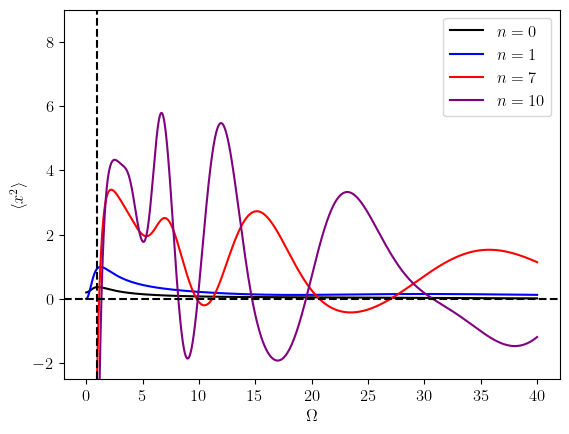

In [62]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

ax.plot(xvals, yvals_0, color='black', label='$n=0$')
ax.plot(xvals, yvals_1, color='blue', label='$n=1$')
ax.plot(xvals, yvals_7, color='red', label='$n=7$')
ax.plot(xvals, yvals_10, color='purple', label='$n=10$')

ax.set_ylim([-2.5, 9])
ax.axhline(0, color='black', linestyle='--')
ax.axvline(1, color='black', linestyle='--')
ax.set_xlabel('$\\Omega$')
ax.set_ylabel('$\\langle x^2 \\rangle$')
ax.legend()

Alright let's get into finding these maxima.

To find the maximum I might as well find the minimum of the negative of the functions, so let's do that. I have to use the bounds to filter out some larger peaks that appear past $\Omega=5$, at least up to $n=10$. I tried some weird functions for the upper bound and the one that's used is the last one before I got tired of trying. It does an okay enough job, but there is surely a way better way to do it. Maybe you can find the minimum that comes right after using SciPy and use that as the upper bound. But I'm not going to bother here, it's in a regime that's not really particularly useful anyway. 

In [9]:
n_vals = np.arange(20)
Omega = np.zeros_like(n_vals) + 0.01 # just making sure it's not assuming it's an array of integers. It will be reassigned anyway. 

for i in range(len(n_vals)):
    Omega[i] = sp.optimize.minimize(lambda x: -1.0 * x_sq_expval_1o(n_vals[i], x), x0=[1.0], bounds=[(1e-6, 3.5 + 1.0*i/40)]).x[0]


In [10]:
print(Omega)

[1.05035742 1.28098845 1.51413442 1.70155609 1.85844267 1.99427093
 2.11474773 2.22345264 2.32340544 2.41125854 2.52531124 3.775
 2.89310473 3.76554583 3.85       3.24046832 3.80307865 3.925
 3.29649731 3.71623115]


Looks reasonable for the smaller n (the cleaner numbers are just hitting the upper bound). Let's plot it and compare. I also quickly ran the code at the very beginning, and then included the plot here. 

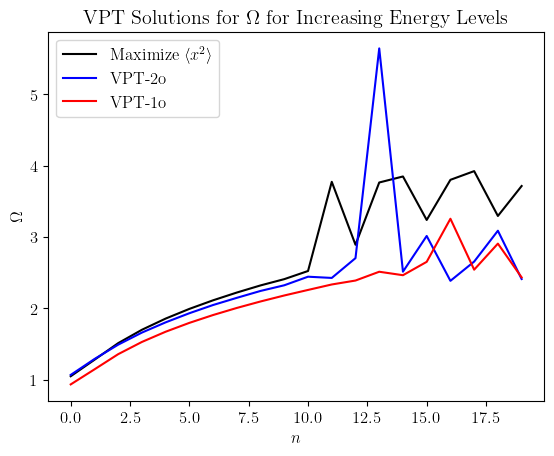

In [40]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

ax.plot(n_vals, Omega, color='black', label='Maximize $\\langle x^2 \\rangle$')
ax.plot(nvals, Omega_2o, label='VPT-2o', color='blue')
ax.plot(nvals, Omega_1o, label='VPT-1o', color='red')

ax.set_title('VPT Solutions for $\\Omega$ for Increasing Energy Levels')
ax.set_ylabel('$\\Omega$')
ax.set_xlabel('$n$')
ax.legend()

It agrees surprisingly well with second order VPT which is interesting. 

We can also find the exact $\langle x^2 \rangle$ by using the Hamiltonian and then finding its eigenvectors to get the numerically exact wavefunction. Let's first find the exact wavefunctions, and then plot them against what we get if we use VPT to calculate the first order correction to the wavefunction. What you'll see is that for $n=0, 1$ VPT basically gets it exactly right, and then there's some disagreement for higher energy levels that exacerbates as $n$ gets larger, particularly near the maxima. VPT tends to overshoot around here, it looks like. 

In [11]:
def exact_wf(n, x):
    Nbasis = 80

    a = np.diag(np.sqrt(np.arange(1, Nbasis)),k=1)
    x_op = ( a + np.transpose(a) )/np.sqrt(2.0)

    H0_mat = np.diag(0.5 + np.arange(Nbasis))
    H1_mat = g*x_op@x_op@x_op@x_op

    energies, wfs = np.linalg.eigh(H0_mat + H1_mat)

    basis_states = np.array([wavefunction(i, x, 0) for i in range(Nbasis)])

    return np.dot(wfs[:, n], basis_states)


In [163]:
xaxis = np.arange(-5, 5, 0.001)
elvl = 0
exact_ground = exact_wf(elvl, xaxis)
wf_vpt1o = wavefunction(elvl, xaxis, Omega[elvl]) + wf_1o_corr(elvl, xaxis, Omega[elvl])

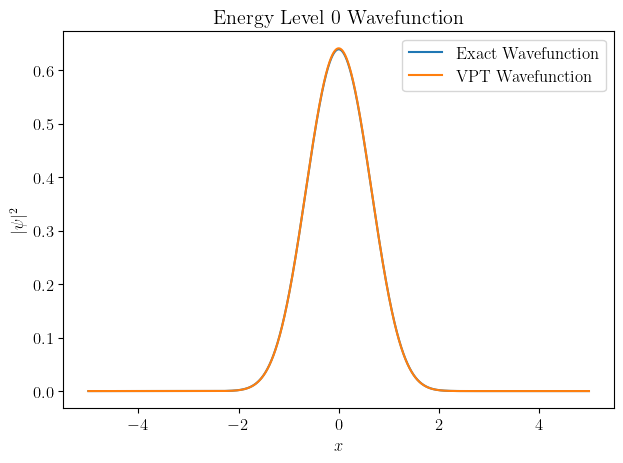

In [164]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

ax.plot(xaxis, exact_ground**2, label="Exact Wavefunction")
ax.plot(xaxis, wf_vpt1o**2, label="VPT Wavefunction")

ax.set_title(f"Energy Level {elvl} Wavefunction")

ax.set_xlabel("$x$")
ax.set_ylabel("$|\\psi|^2$")

ax.legend()
fig.tight_layout()

Here's something else that's interesting: if you see the differences in the wavefunctions they actually look like polynomials with some exponential drop off when $x$ gets large. I've done it for the ground state below but you can play around with elvl and see that the difference becomes a higher and higher order polynomial. 

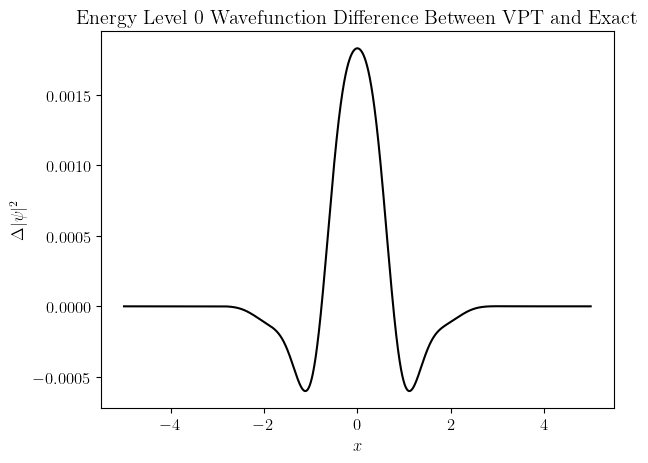

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

ax.plot(xaxis, wf_vpt1o**2 -  exact_ground**2, color='black')

ax.set_title(f"Energy Level {elvl} Wavefunction Difference Between VPT and Exact")

ax.set_xlabel("$x$")
ax.set_ylabel("$\\Delta |\\psi|^2$")

fig.tight_layout()
ax.legend()

Another interesting thing you can play with is that if you plot this same comparison for higher energy values, you will see a lot of discrepancy very early if you just use the $\Omega$ value retrieved for the grounds state wavefunction. The fit is much better if the $\Omega$ value used corresponds to the energy level that's used in the VPT procedure. To test this you can change Omega[elvl] in the wf_vpt1o calculation and plot it again, and see for yourself. 

Let's now see how $\langle x^2 \rangle$ compares between the two as the energy level increases. I'll just do this up to $n=10$ since soon after that the results for $\Omega$ start to get a bit weird. But to be sure you can always change "length" below and see for yourself. 

In [12]:
# zeroth-order integrand for x^2 expectation value
def x_sq_integrand_exact(n, x):
    return exact_wf(n, x) * (x)**2 * exact_wf(n, x)

#zeroth-order x^2 expectation value
def x_sq_expval_exact(n):
    return c1 * np.dot(weights, x_sq_integrand_exact(n, c1*samples + c2))

Text(0.5, 1.0, 'Difference in $\\langle x^2 \\rangle$ Between Exact and VPT')

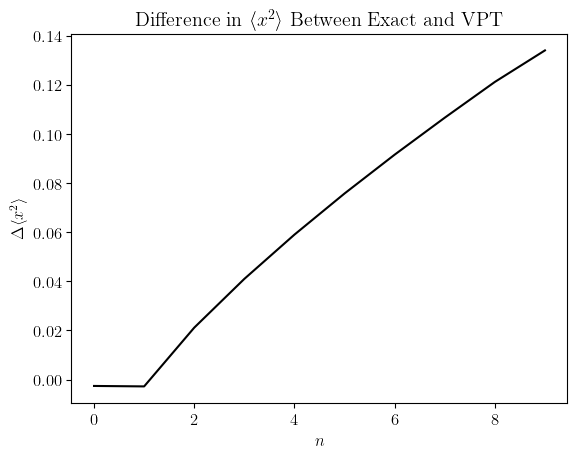

In [20]:
length = 10
x_sq_diff = [x_sq_expval_1o(i, Omega[i]) - x_sq_expval_exact(i) for i in range(length)]

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot(np.arange(length), x_sq_diff, color='black')

ax.set_xlabel('$n$')
ax.set_ylabel('$\\Delta \\langle x^2 \\rangle$')
ax.set_title("Difference in $\\langle x^2 \\rangle$ Between Exact and VPT")

We can now move onto making heatmaps of the $\Omega$ values we've found, the most important being the ground state. 

In [21]:
size = 13
energy_matrix1 = np.zeros((size, size))

for i in range(size):
    for j in range(i, size):
        integral = c1 * np.dot(weights, trans_amp(i, j, c1*samples + c2, 0))

        energy_matrix1[i][j] = integral
        energy_matrix1[j][i] = integral


energy_matrix2 = np.zeros((size, size))
test1 = 0
for i in range(size):
    for j in range(i, size):
        integral = c1 * np.dot(weights, trans_amp(i, j, c1*samples + c2, Omega[test1]))

        energy_matrix2[i][j] = integral
        energy_matrix2[j][i] = integral


energy_matrix3 = np.zeros((size, size))
test2 = 5
for i in range(size):
    for j in range(i, size):
        integral = c1 * np.dot(weights, trans_amp(i, j, c1*samples + c2, Omega[test2]))

        energy_matrix3[i][j] = integral
        energy_matrix3[j][i] = integral


energy_matrix4 = np.zeros((size, size))
test3 = 10
for i in range(size):
    for j in range(i, size):
        integral = c1 * np.dot(weights, trans_amp(i, j, c1*samples + c2, Omega[test3]))

        energy_matrix4[i][j] = integral
        energy_matrix4[j][i] = integral


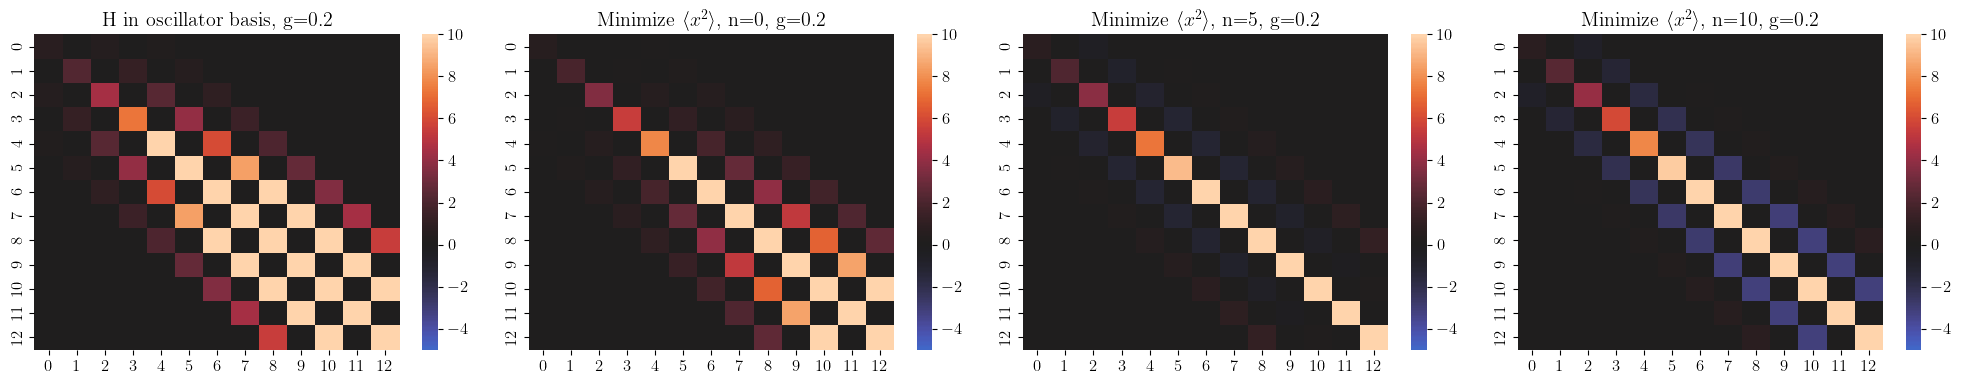

In [37]:
fig = plt.figure(figsize=(20, 4))
ax1 = fig.add_subplot(1, 4, 1)
ax2 = fig.add_subplot(1, 4, 2)
ax3 = fig.add_subplot(1, 4, 3)
ax4 = fig.add_subplot(1, 4, 4)
ax1.set_title('H in oscillator basis, g=0.2')
ax2.set_title(f'Minimize $\\langle x^2 \\rangle$, n={test1}, g={g}')
ax3.set_title(f'Minimize $\\langle x^2 \\rangle$, n={test2}, g={g}')
ax4.set_title(f'Minimize $\\langle x^2 \\rangle$, n={test3}, g={g}')
sns.heatmap(energy_matrix1, ax=ax1, vmax = 10, vmin=-5, cmap='icefire', center=0)
sns.heatmap(energy_matrix2, ax=ax2, vmax = 10, vmin=-5, cmap='icefire', center=0)
sns.heatmap(energy_matrix3, ax=ax3, vmax = 10, vmin=-5, cmap='icefire', center=0)
sns.heatmap(energy_matrix4, ax=ax4, vmax = 10, vmin=-5, cmap='icefire', center=0)

fig.tight_layout()
plt.show()
